# Beskrivning av projektet 

1. Infrastruktur och Säkerhet (AWS-kontot)
Skapade AWS-kontot, IAM-användare och S3 Bucket (lade också in ett "Billing Alarm" på 1 USD).

2. Bildinsamling (Data Sourcing)
Letade upp 50 bra bilder från mina resor och lade i en mapp på min hemsida: https://intertec.se/Rekognition/ (öppen för bläddring som mapp via .htaccess-modifiering).

3. Bildanalys med Amazon Rekognition
Hämtade bilderna från intertec.se och skicka upp till min S3-bucket
Python-scriptet loopar sedan igenom bilderna i Amazon Rekognition och sparar ned labels lokalt

4. Sammanställning och Visualisering
Lite meck med att sovra bland alla labels och hitta något vettigt att visualisera. Tog den "viktigaste" labeln per bild, antal identifierade labels per bild och labbade lite i allmänhet.

Visualiserade labels direkt i Jupyter Notebook istf att köra externt.

5. Avslutning
Såg till att allt var commitat och klart (utom .env med nycklarna och lite annat bös).


In [ ]:
# Hämta bilder, ladda upp till Amazon, hämta analysen och visualisera

import os
import requests
import boto3
import pandas as pd
from bs4 import BeautifulSoup
from dotenv import load_dotenv

# 1. Ladda inställningar
load_dotenv()
BUCKET_NAME = os.getenv('S3_BUCKET_NAME')
REGION = os.getenv('AWS_REGION')
URL = "https://intertec.se/Rekognition/"

# Initiera AWS-klienter
s3 = boto3.client('s3', region_name=REGION)
rekognition = boto3.client('rekognition', region_name=REGION)

# 2. Hämta bilder från min hemsida
print(f"Hämtar bildlista från {URL}...")
response = requests.get(URL)
soup = BeautifulSoup(response.text, 'html.parser')

# Kontrollera att endast bilder används
image_links = []
for a in soup.find_all('a'):
    href = a.get('href')
    if href.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_links.append(href)

print(f"Hittade {len(image_links)} bilder.")

# 3. Bearbeta bilderna
all_data = []

for img_name in image_links:
    full_url = URL + img_name
    
    # Ladda in bild i minnet
    img_response = requests.get(full_url)
    img_bytes = img_response.content
    
    # Tanka upp till S3
    s3.put_object(Bucket=BUCKET_NAME, Key=img_name, Body=img_bytes)
    
    # Analysera med Rekognition
    response = rekognition.detect_labels(
        Image={'S3Object': {'Bucket': BUCKET_NAME, 'Name': img_name}},
        MaxLabels=10,
        MinConfidence=80 # 80% får vara minimumkvalitet
    )
    
    # Spara resultaten
    for label in response['Labels']:
        all_data.append({
            'Image': img_name,
            'Label': label['Name'],
            'Confidence': label['Confidence']
        })
    print(f"Klar med: {img_name}")

# 4. Spara till CSV
df = pd.DataFrame(all_data)
df.to_csv('rekognition_results.csv', index=False)
print("\nSuccé! All data har sparats till 'rekognition_results.csv'.")

Hämtar bildlista från https://intertec.se/Rekognition/...
Hittade 63 bilder. Påbörjar molnprocessering...
Klar med: Colin%20NSW%20(1).jpg
Klar med: Colin%20NSW%20(2).jpg
Klar med: Colin%20NSW%20(3).jpg
Klar med: Colin%20Will%20o%20Declan%20-%20br%c3%b6der%20for%20life.jpg
Klar med: Colin%20och%20Mark%20Matehaere%20p%c3%a5%20NSW.jpg
Klar med: Colin%20och%20hans%20f%c3%b6r%c3%a4ldrar%20framf%c3%b6r%20Strathfields%20klubbhus.JPG
Klar med: Colin%20vann.jpg
Klar med: Colin.jpg
Klar med: Creepy%20crawlies.jpg
Klar med: Djurliv.jpg
Klar med: Furrows.jpg
Klar med: Gr%c3%a4s.jpg
Klar med: Handkratta%202.jpg
Klar med: Handkratta.jpg
Klar med: Hejd%c3%a5%20jobbet.jpg
Klar med: I%20kalla%20Sverige.jpg
Klar med: IMG_0166.jpg
Klar med: IMG_3208.jpg
Klar med: IMG_3668.jpg
Klar med: IMG_8134.jpg
Klar med: IMG_8137.jpg
Klar med: IMG_8141.JPG
Klar med: IMG_8142.jpg
Klar med: IMG_8143.JPG
Klar med: IMG_8148.JPG
Klar med: IMG_8151.jpg
Klar med: IMG_8155.JPG
Klar med: IMG_8157.JPG
Klar med: IMG_8161.jpg
Kl

In [8]:
# Städa bort 13 bilder för att komma till 50 - och sparar några jag vill ha som exempel

# 1. Ladda in data från Rekognition-jobbet
df = pd.read_csv('rekognition_results.csv')

# 2. Spara några favoriter
mandatory_images = [
    'Operahuset.jpg', 
    'Kangaroo%201.JPG', 
    'IMG_8134.jpg', 
    'Creepy%20crawlies.jpg'
]

# 3. Skapa urvalet
all_unique = [img for img in df['Image'].unique() if img != 'På jobbet.jpg' and img not in mandatory_images]

# Fyll på med 46 bilder till
selection = mandatory_images + all_unique[:46]

# 4. Spara den slutgiltiga listan
df_final = df[df['Image'].isin(selection)].copy()
df_final.to_csv('rekognition_results_final.csv', index=False)

print(f"Klart! 'rekognition_results_final.csv' har skapats med {df_final['Image'].nunique()} bilder.")

Klart! 'rekognition_results_final.csv' har skapats med 50 bilder.


C:\Users\micha\AppData\Local\Temp\ipykernel_33380\2718722561.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_labels.values, y=top_labels.index, palette="viridis")


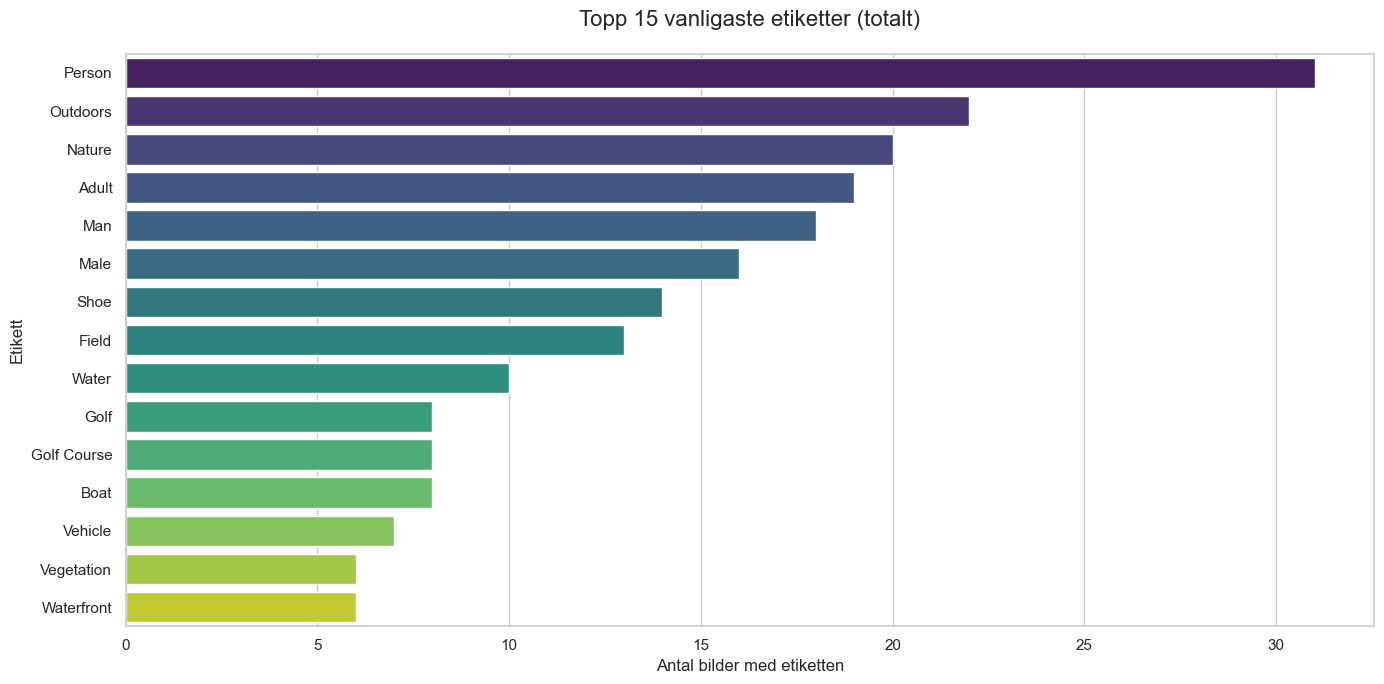

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurera layouten
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7)) 

# Räkna labels
top_labels = df_final['Label'].value_counts().head(15)

# Skapa diagrammet
sns.barplot(x=top_labels.values, y=top_labels.index, palette="viridis")

plt.title('Topp 15 vanligaste etiketter (totalt)', fontsize=16, pad=20)
plt.xlabel('Antal bilder med etiketten', fontsize=12)
plt.ylabel('Etikett', fontsize=12)

plt.tight_layout()
plt.show()

Noterbart är att Amazon Rekognition är lite "dum" och skiljer på "Man" och "Male" samt "Golf" och "Golf Course". Även Outdoors och Nature är tveksamt. Water och Waterfront också kanske? 

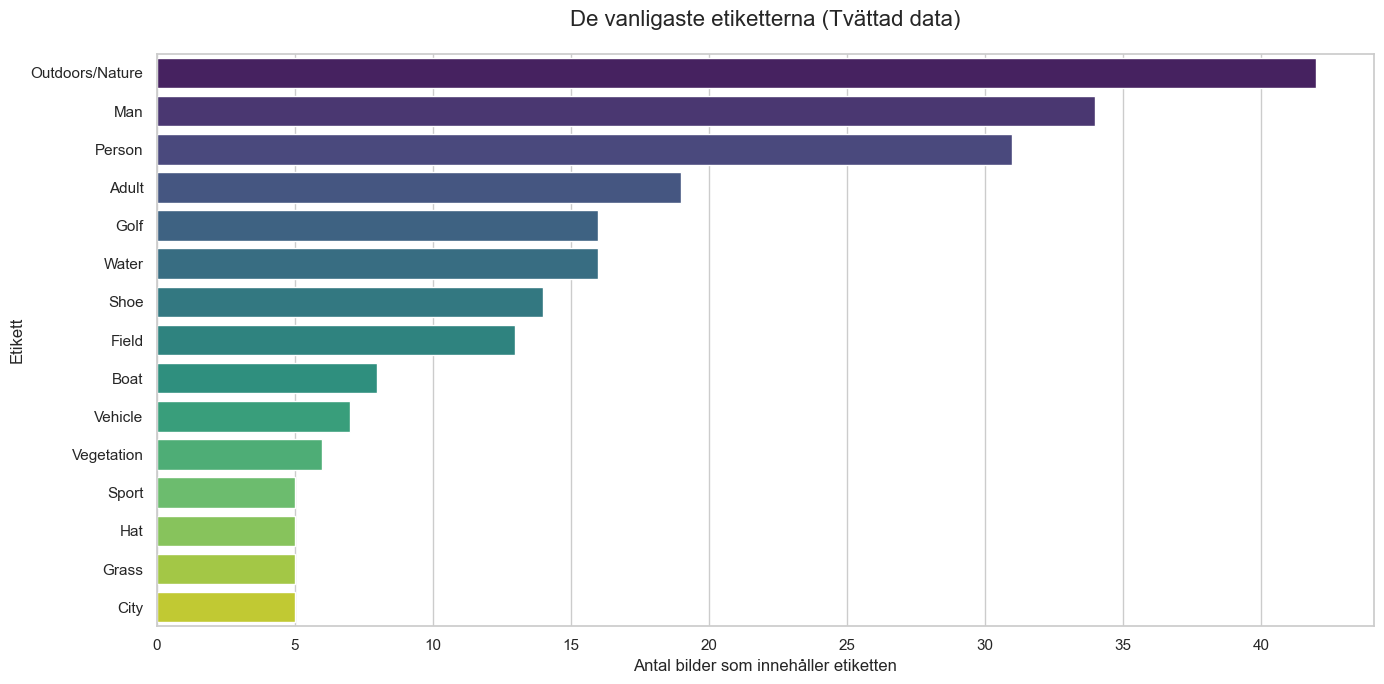

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ladda data
df_final = pd.read_csv('rekognition_results_final.csv')

# 2. Tvätta datan (Sammanslagning av kategorier)
cleanup_map = {
    'Male': 'Man',
    'Golf Course': 'Golf',
    'Nature': 'Outdoors/Nature',
    'Outdoors': 'Outdoors/Nature',
    'Waterfront': 'Water'
}
df_final['Label'] = df_final['Label'].replace(cleanup_map)

# 3. Visualisera
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

top_labels = df_final['Label'].value_counts().head(15)

# Fick en irriterande "future warning" så här sätter jag y till hue och legend=False för att tysta varningen
sns.barplot(
    x=top_labels.values, 
    y=top_labels.index, 
    hue=top_labels.index, 
    palette="viridis", 
    legend=False
)

plt.title('De vanligaste etiketterna (Tvättad data)', fontsize=16, pad=20)
plt.xlabel('Antal bilder som innehåller etiketten', fontsize=12)
plt.ylabel('Etikett', fontsize=12)

plt.tight_layout()
plt.show()

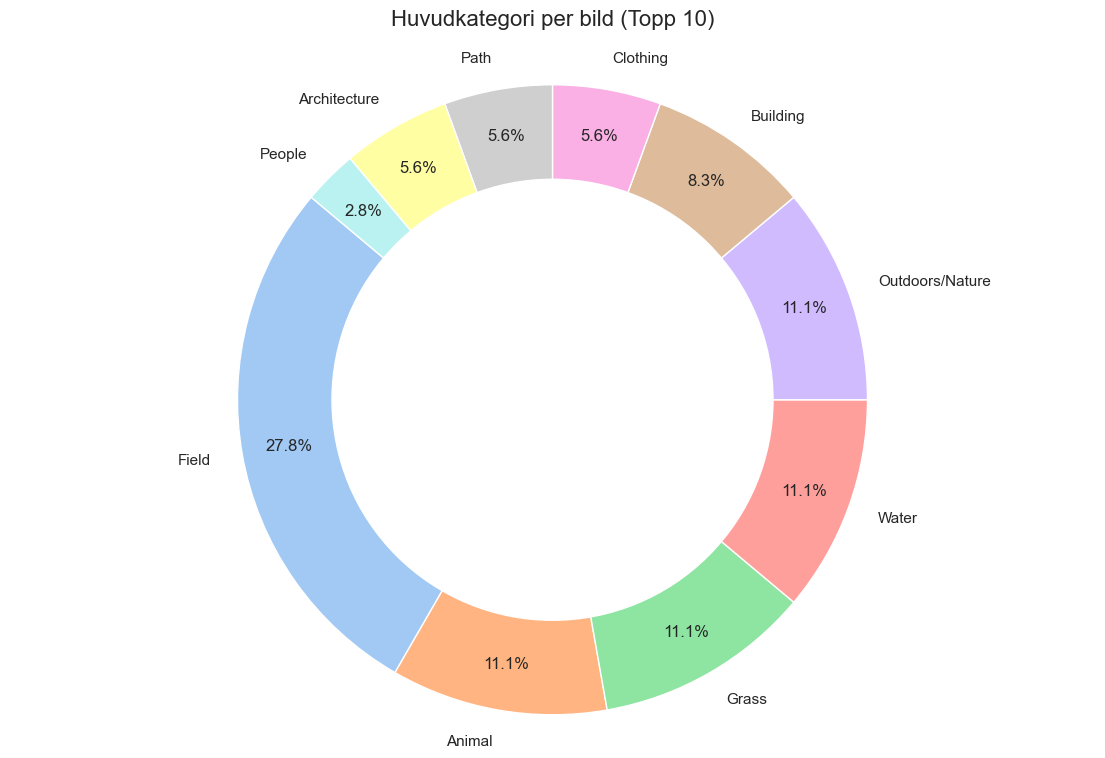

In [14]:
plt.figure(figsize=(14, 9))

# 1. Hitta etiketten med högst konfidens för varje bild
primary_labels = df_final.loc[df_final.groupby('Image')['Confidence'].idxmax()]

# 2. Räkna topp 10
category_counts = primary_labels['Label'].value_counts().head(10)

# 3. Skapa diagrammet
colors = sns.color_palette("pastel", 10)
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, pctdistance=0.85)

# 4. Donut-hål (nu blev jag sugen på donuts ...)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Huvudkategori per bild (Topp 10)', fontsize=16, pad=20)
plt.axis('equal') 
plt.show()

Några bilder med labels



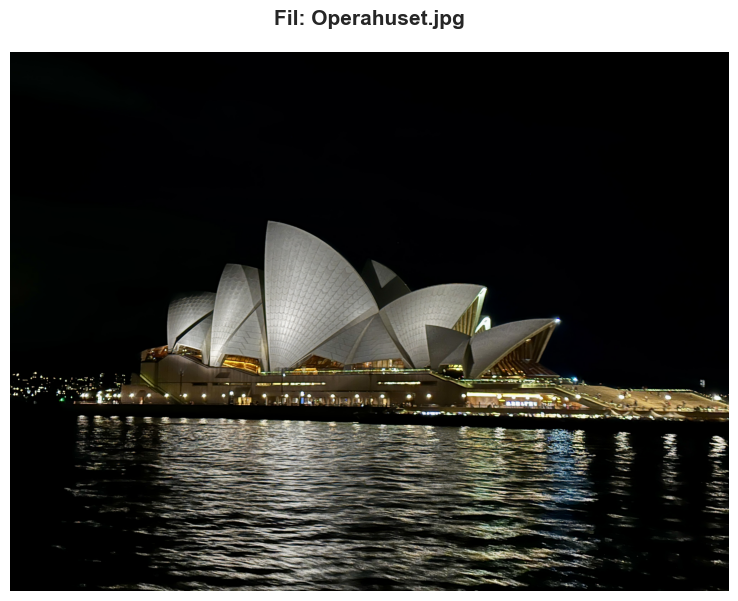

AI-identifierade etiketter för Operahuset.jpg:
  • Architecture: 93.42%
  • Building: 93.42%
  • Landmark: 87.75%
  • Sydney Opera House: 87.75%




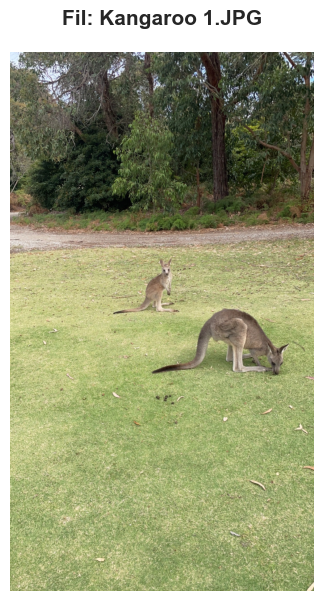

AI-identifierade etiketter för Kangaroo 1.JPG:
  • Animal: 98.75%
  • Kangaroo: 98.75%
  • Mammal: 98.75%




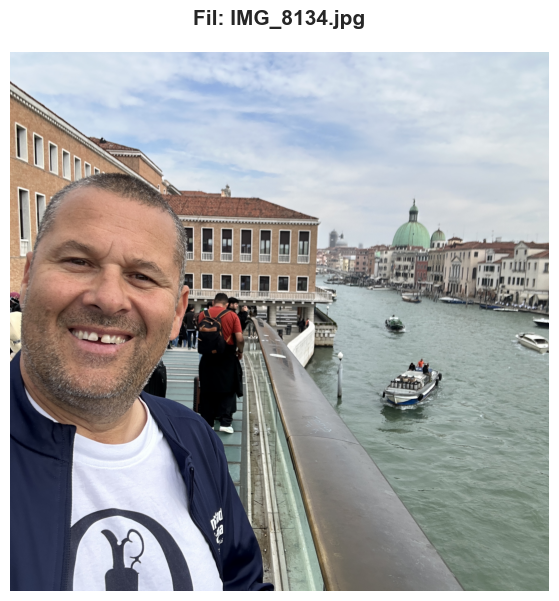

AI-identifierade etiketter för IMG_8134.jpg:
  • Water: 100.00%
  • Person: 99.99%
  • Photography: 99.99%
  • Portrait: 99.99%
  • City: 99.95%
  • Neighborhood: 99.62%
  • Boat: 99.61%
  • Metropolis: 99.52%
  • Adult: 99.48%
  • Man: 99.48%




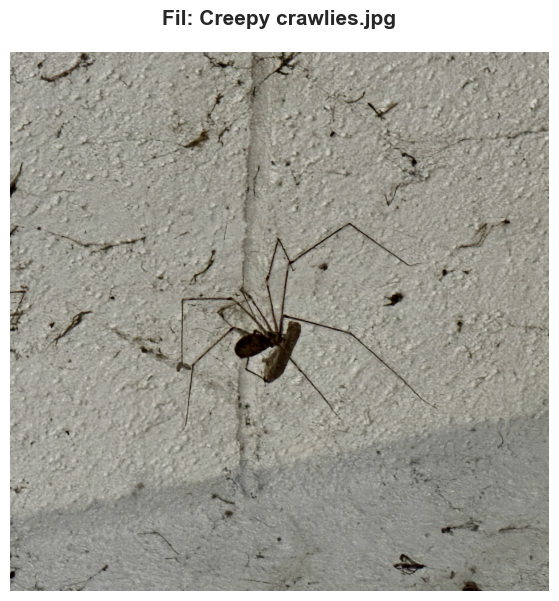

AI-identifierade etiketter för Creepy crawlies.jpg:
  • Animal: 97.79%
  • Invertebrate: 97.79%
  • Spider: 97.79%
  • Insect: 95.38%




In [15]:
import requests
from io import BytesIO
from PIL import Image as PILImage

BASE_URL = "https://intertec.se/Rekognition/"

# Utvalda bilder som exempel
example_images = [
    'Operahuset.jpg', 
    'Kangaroo%201.JPG', 
    'IMG_8134.jpg', 
    'Creepy%20crawlies.jpg'
]

print("Några bilder med labels\n")

for img_name in example_images:
    # Hämta data för bilden
    img_data = df_final[df_final['Image'] == img_name].sort_values(by='Confidence', ascending=False)
    
    if img_data.empty:
        print(f"Hittade ingen data för: {img_name}")
        continue

    # 1. Visa bilden
    plt.figure(figsize=(12, 7))
    try:
        # Fixar URL-kodning för blanksteg i namnen
        response = requests.get(BASE_URL + img_name, timeout=10)
        img = PILImage.open(BytesIO(response.content))
        
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Fil: {img_name.replace('%20', ' ')}", fontsize=15, fontweight='bold', pad=20)
        plt.show()
        
        # 2. Skriv ut alla labels som en lista under bilden
        print(f"AI-identifierade etiketter för {img_name.replace('%20', ' ')}:")
        
        # Ta bort ev. dubbletter
        unique_labels = img_data.drop_duplicates(subset=['Label'])
        
        for _, row in unique_labels.iterrows():
            print(f"  • {row['Label']}: {row['Confidence']:.2f}%")
            
        print("\n" + "="*80 + "\n")
        
    except Exception as e:
        print(f"Kunde inte ladda bild {img_name}: {e}")